In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


# assume two boreholes: x=0, x=1
mu = np.array([35.0, 35.0])
# mean rmr, static for now

sigma_sq = 8 ** 2 # variance, sigma of 8
rho = 0.8 # assume strong similarity coeff for short distance
# how calc in real? / literature
# we use kernel that auto calcs based on diff between the pairs

sigma = np.array([[sigma_sq, rho * sigma_sq], [rho*sigma_sq, sigma_sq]])

# 2x2 matrix, diagonal elements covar with onself
# couldnt just say [1,0.8] [0.8, 1]?

# TWO BOREHOLES AS A MULTIVARIATE


samples = np.random.multivariate_normal(mu, sigma, size=5) # 5 indepdent sampling pairs for joint distro of two boreholes (mu has 2 elements)

print(f"\n5 joint samples of (RMR_BH1, RMR_BH2):")
for i, s in enumerate(samples):
    # i is the box counter, s is the item counter inside the box
    print(f" Sample {i+1}: BH-1 = {s[0]:.1f}, BH-2={s[1]:.1f}")


In [ ]:
x = [0, 1, 2, 4, 5]
n = len(x)
mu_n = np.full(n, 35.0)# mu for 5 boreholes, constant priors

# kernel is simply a formula/calc for values in the covar matrix
# here we use a simple RBF kernel
#   k(x, x') = σ² * exp(-|x - x'|² / (2ℓ²))
# l is length-scale; how far aprt two points can be and still be corr

sigma_sq = 8 **2
ell = 2 #km

# compute 5x5 covar matrix

k = np.zeros((n, n)) # tuple
for i in range(n):
    for j in range(n):
        dist_sq = (x[i]-x[j]) ** 2
        k[i,j] = sigma_sq * np.exp(-dist_sq / (2*ell**2))


print("\n=== 5 BOREHOLES: COVARIANCE MATRIX FROM RBF KERNEL ===")
print(f"Locations:    x = {x} km")
print(f"Length-scale: ℓ = {ell} km")
print(f"Signal var:   σ² = {sigma_sq}")
print(f"\nCovariance matrix k:")
print(np.array2string(k, precision=2, suppress_small=True))
print(f"\nDiagonal (variances):  {np.diag(k).round(2)}")
print(f"K[0,1] (0-1km apart): {k[0,1]:.2f} — high correlation")
print(f"K[0,3] (0-4km apart): {k[0,3]:.2f} — low correlation")
print(f"K[0,4] (0-5km apart): {k[0,4]:.2f} — very low correlation")
print(f"\n→ Points close together (< ℓ) are highly correlated.")
print(f"→ Points far apart (> 2ℓ) are nearly independent.")
print(f"→ The length-scale ℓ = {ell} km controls this boundary.")

In [ ]:
# draw fxn from gp prior


x_dense =np.linspace(0, 5, 200)
n_dense = len(x_dense)
mu_dense = np.full(n_dense, 35.0) # before seeing data we assign all BH a mean of 35

# rbf kernel -> 200x200 matrix but same line of code

k_dense = np.zeros((n_dense, n_dense))
for i in range(n_dense):
    for j in range(n_dense):
        dist_sq = (x_dense[i] - x_dense[j])**2
        k_dense[i,j] = sigma_sq * np.exp(-dist_sq / (2 * ell**2))

# Add a tiny nugget for numerical stability (Cholesky needs positive definite; not zero, not negative inside root)
k_dense += 1e-6 * np.eye(n_dense)

# np.eye crete 2d identity matrix

prior_samples = np.random.multivariate_normal(mu_dense, k_dense, size = 10)

# we picking like 200 heights 10 times for 200 x values (mu)
#when you set size=10, NumPy does not just pick 10 independent numbers. It generates 10 distinct groups (vectors) of numbers.

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(x_dense, prior_samples[i], alpha=0.5, linewidth=1.5)

plt.axhline(y=35, color='black', linestyle='--', alpha=0.3, label='Mean (35)')
plt.fill_between(x_dense,
                  35 - 2*np.sqrt(sigma_sq),
                  35 + 2*np.sqrt(sigma_sq),
                  alpha=0.1, color='gray', label='±2σ prior band')
plt.xlabel('Chainage (km)')
plt.ylabel('RMR Value')
plt.title(f'GP PRIOR: 10 Random Functions (ℓ={ell} km, σ²={sigma_sq})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Each colored line is a PLAUSIBLE RMR profile along the tunnel.
#Before seeing any data, the GP says: 'ANY of these could be reality.
#They all hover around the mean (35) and stay within ±2σ.
#They are SMOOTH because ℓ={ell} km — the kernel enforces smoothness.
#After conditioning on borehole data, most of these will be eliminated.

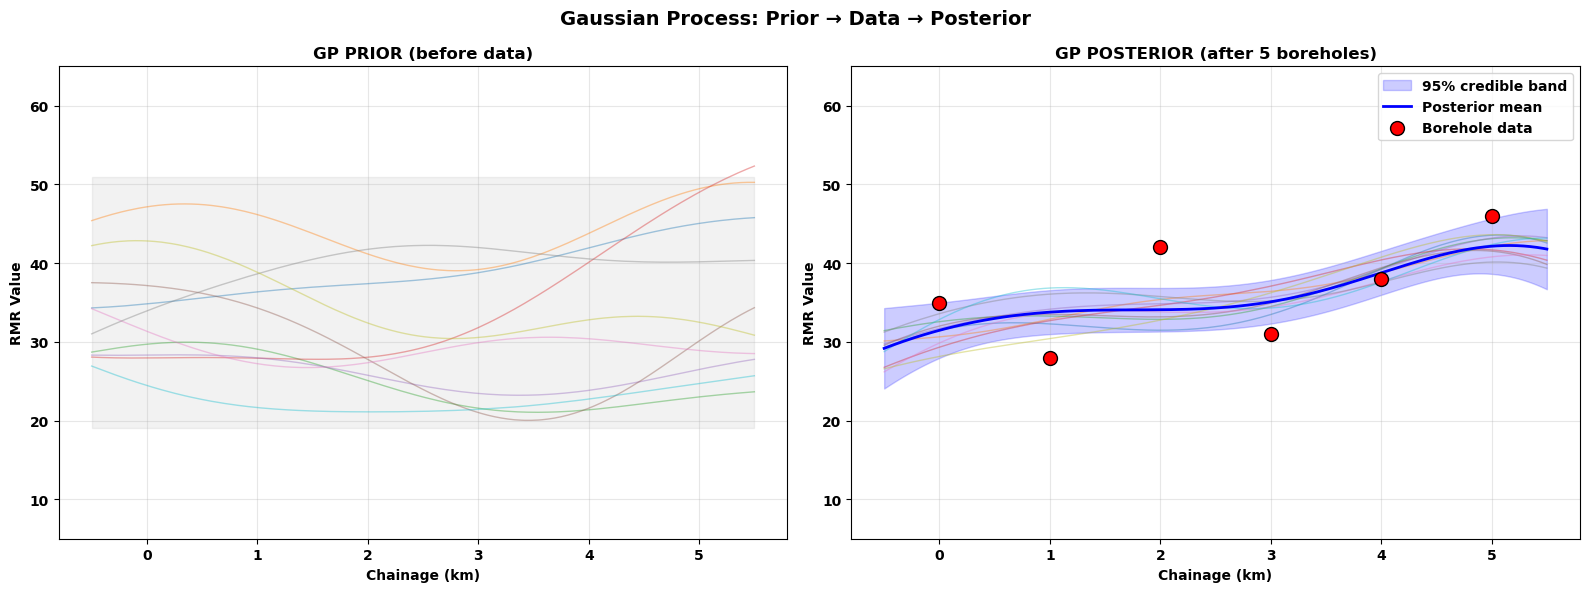

In [ ]:
# condition on data; gp posterior

x_obs = np.array([0, 1 , 2, 3, 4, 5]) # obs data
y_obs = np.array([35.0, 28.0, 42.0, 31.0, 38.0, 46.0])

x_star = np.linspace(-0.5, 5.5, 200)
# we want to predict in these places, smooth fxn

noise_var = 2 **2 # sigma is 2, diff from the nugget? epistemic noise?

def rbf_kernel(xa, xb, sigma_sq, ell):
    # convert the matrix to 2d matrix
    # if [1,2, 3] its shape is 3 elements but run the atleats2d gives it shape of 1,3 one row 3 col and .T makes it a column matrix
    # change for matrix mult
    xa = np.atleast_2d(xa).T if xa.ndim == 1 else xa
    xb = np.atleast_2d(xb).T if xb.ndim == 1 else xb
    dist_sq = np.sum(xa**2, 1).reshape(-1, 1) + np.sum(xb**2, 1) - (2 * xa @ xb.T)
    # (A - B)² = A² + B² - 2AB
    return sigma_sq * np.exp(-dist_sq / (2 * ell**2))

# efficient way to calc eucladian distances

k_XX = rbf_kernel(x_obs, x_obs, sigma_sq, ell) + noise_var * np.eye(len(x_obs))
k_XsX = rbf_kernel(x_star, x_obs, sigma_sq, ell)
k_XsXs = rbf_kernel(x_star, x_star, sigma_sq, ell)
# x*x* for uncertainity band

# why no noise param on others
# The noise parameter represents measurement error or sensor noise which ofc is only on obs data

# to predict, we must know how everything (co) relates with everything else
k_XX_inv = np.linalg.inv(k_XX)
# a proper method is choleksy decomp, sovling another LE
#print("k_XsX shape:   ", k_XsX.shape)   # Expected: (M, N)
#print("k_XX_inv shape:", k_XX_inv.shape) # Expected: (N, N)
#print("y_obs shape:   ", y_obs.shape) # expected (N)

# acutal math behind is a set of LA solving
mu_post = k_XsX @ k_XX_inv @ y_obs
sigma_post = k_XsXs - k_XsX @ k_XX_inv @ k_XsX.T

# Standard deviation at each prediction point
std_post = np.sqrt(np.diag(sigma_post))

posterior_samples = np.random.multivariate_normal(
    mu_post, sigma_post + 1e-6 * np.eye(len(x_star)), size=10
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Prior
for i in range(10):
    # Reuse prior_samples from earlier, but on x_dense (0 to 5)
    pass  # (already plotted above)
axes[0].set_title(f'GP PRIOR (before data)')
for i in range(10):
    # Re-draw for this plot
    ps = np.random.multivariate_normal(
        np.full(len(x_star), 35.0),
        rbf_kernel(x_star, x_star, sigma_sq, ell) + 1e-6 * np.eye(len(x_star)),
    )
    axes[0].plot(x_star, ps, alpha=0.4, linewidth=1)
axes[0].fill_between(x_star, 35 - 2*np.sqrt(sigma_sq), 35 + 2*np.sqrt(sigma_sq),
                      alpha=0.1, color='gray')
axes[0].set_xlabel('Chainage (km)')
axes[0].set_ylabel('RMR Value')
axes[0].set_ylim(5, 65)
axes[0].grid(True, alpha=0.3)

# Right: Posterior
for i in range(10):
    axes[1].plot(x_star, posterior_samples[i], alpha=0.4, linewidth=1)
axes[1].fill_between(x_star, mu_post - 2*std_post, mu_post + 2*std_post,
                      alpha=0.2, color='blue', label='95% credible band')
axes[1].plot(x_star, mu_post, 'b-', linewidth=2, label='Posterior mean')
axes[1].scatter(x_obs, y_obs, c='red', s=100, zorder=5, edgecolors='black',
                label='Borehole data')
axes[1].set_xlabel('Chainage (km)')
axes[1].set_ylabel('RMR Value')
axes[1].set_title(f'GP POSTERIOR (after 5 boreholes)')
axes[1].legend()
axes[1].set_ylim(5, 65)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gaussian Process: Prior → Data → Posterior', fontsize=14)
plt.tight_layout()

plt.show()

#PRIOR: Functions wander freely within ±2σ of the mean.
#POSTERIOR: Functions are PINNED at the data points.
#BETWEEN data points: Functions fan out — uncertainty GROWS.
#FAR from data: Posterior reverts to the prior (wide bands).
#The BAND WIDTH is the uncertainty. Narrow = confident. Wide = ignorant.
#This is the GP's killer capability:
#At chainage 3.0 km (no borehole), RMR = 36.2 ± 7.1'
#At chainage 1.0 km (borehole BH-2), RMR = 28.0 ± 2.0'
#The GP KNOWS where it knows and where it doesn't.